## Test

In [12]:
import numpy as np
import pandas as pd

# 加载 .npz 文件
data = np.load('../singleset/Holstein75_256bd.npz',allow_pickle=True)

# 'mol list', 'tempearture', 'total time', 'other info', 'r square array', 
# 'electron occupations array', 'phonon occupations array', 'k occupations array', 
# 'eph entropy', 'bond entropy', 'coherent length array', 'time series'
df = data['electron occupations array']

df = pd.DataFrame(df)

df.to_excel('Holstein75_256bd_singleset.xlsx', index=False)

## Plot RMSD



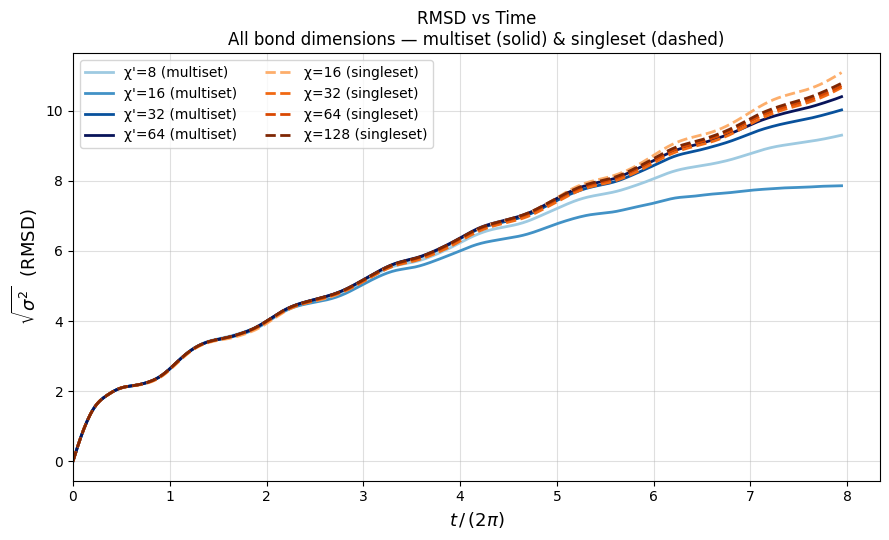

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本参数
# =========================
dt = 0.1  # a.u.

# =========================
# 计算 RMSD 的函数
# =========================
def compute_rmsd(file_path):
    df = pd.read_excel(file_path, header=None)
    occup = df.values  # shape: (Nt, Nsite)

    Nt, Nsite = occup.shape
    n0 = (Nsite - 1) / 2
    x = np.arange(Nsite)

    rmsd = np.zeros(Nt)
    for t in range(Nt):
        rho = occup[t]
        norm = np.sum(rho)
        if norm > 0:
            rho = rho / norm
        rmsd[t] = np.sqrt(np.sum((x - n0)**2 * rho))

    time_au = np.arange(Nt) * dt
    time_scaled = time_au / (2 * np.pi)
    return time_scaled, rmsd

# =========================
# 收集所有涉及的文件（去重），并标注来源组
# =========================

# multiset 组所有文件（按 bond dim 从小到大）
files_multiset = [
    ("χ'=8",   "Holstein75_8bd_multiset.xlsx"),
    ("χ'=16",  "Holstein75_16bd_multiset.xlsx"),
    ("χ'=32",  "Holstein75_32bd_multiset.xlsx"),
    ("χ'=64",  "Holstein75_64bd_multiset.xlsx"),   # 作为 χ'=32 的参考，也画出来
]

# singleset 组所有文件（按 bond dim 从小到大）
files_singleset = [
    ("χ=16",   "Holstein75_16bd_singleset.xlsx"),
    ("χ=32",   "Holstein75_32bd_singleset.xlsx"),
    ("χ=64",   "Holstein75_64bd_singleset.xlsx"),
    ("χ=128",  "Holstein75_128bd_singleset.xlsx"),  # 作为 χ=64 的参考，也画出来
]

# =========================
# 颜色配置
# multiset:  实线，蓝绿色系，bond dim 从小到大颜色从浅到深
# singleset: 虚线，橙红色系，bond dim 从小到大颜色从浅到深
# =========================
colors_multiset  = ["#9ecae1", "#4292c6", "#08519c", "#08145a"]  # 浅蓝→深蓝
colors_singleset = ["#fdae6b", "#f16913", "#d94801", "#7f2704"]  # 浅橙→深橙

# =========================
# 绘图：所有文件的 RMSD
# =========================
fig, ax = plt.subplots(figsize=(9, 5.5))

# --- multiset 组（实线）---
for (label, file_path), color in zip(files_multiset, colors_multiset):
    try:
        time, rmsd = compute_rmsd(file_path)
        ax.plot(time, rmsd, lw=2, ls="-", color=color, label=f"{label} (multiset)")
    except FileNotFoundError:
        print(f"[Warning] 文件未找到，已跳过：{file_path}")

# --- singleset 组（虚线）---
for (label, file_path), color in zip(files_singleset, colors_singleset):
    try:
        time, rmsd = compute_rmsd(file_path)
        ax.plot(time, rmsd, lw=2, ls="--", color=color, label=f"{label} (singleset)")
    except FileNotFoundError:
        print(f"[Warning] 文件未找到，已跳过：{file_path}")

# =========================
# 图像设置
# =========================
ax.set_xlim(left=0)
ax.set_xlabel(r"$t\,/\,(2\pi)$", fontsize=13)
ax.set_ylabel(r"$\sqrt{\sigma^2}$  (RMSD)", fontsize=13)
ax.set_title("RMSD vs Time\n"
             "All bond dimensions — multiset (solid) & singleset (dashed)",
             fontsize=12)
ax.legend(fontsize=10, ncol=2, loc="upper left")
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
# plt.savefig("All_RMSD.png", dpi=150)
plt.show()

## related error


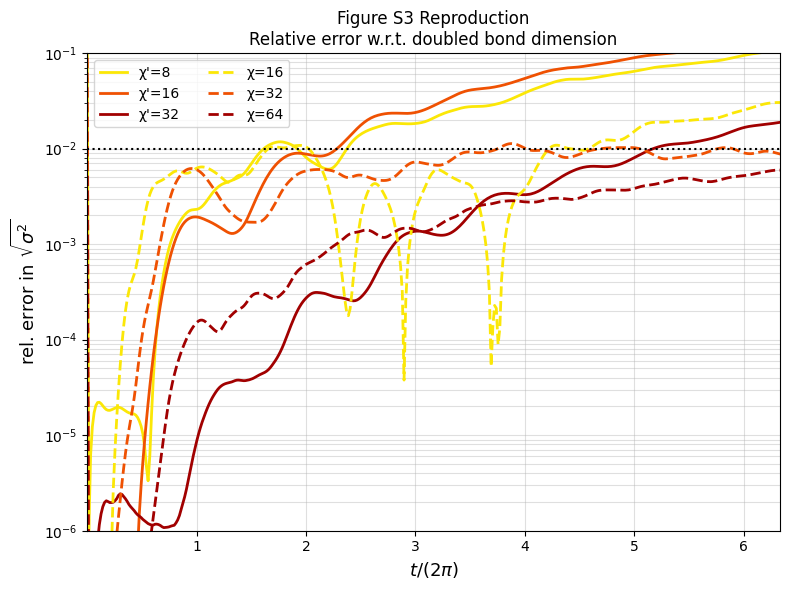

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本参数
# =========================
dt = 0.1  # a.u.

# =========================
# 计算 RMSD 的函数
# =========================
def compute_rmsd(file_path):
    df = pd.read_excel(file_path, header=None)
    occup = df.values  # shape: (Nt, Nsite)

    Nt, Nsite = occup.shape
    n0 = (Nsite - 1) / 2
    x = np.arange(Nsite)

    rmsd = np.zeros(Nt)
    for t in range(Nt):
        rho = occup[t]
        norm = np.sum(rho)
        if norm > 0:
            rho = rho / norm
        rmsd[t] = np.sqrt(np.sum((x - n0)**2 * rho))

    time_au = np.arange(Nt) * dt
    time_scaled = time_au / (2 * np.pi)
    return time_scaled, rmsd

# =========================
# 文件定义：(低bd文件, 参考=2倍bd文件)
# 严格按照文章：每条曲线的参考是其翻倍bd的计算
# =========================

# multiset 组：参考是翻倍的 multiset
pairs_multiset = [
    ("χ'=8",  "Holstein75_8bd_multiset.xlsx",   "Holstein75_16bd_multiset.xlsx"),
    ("χ'=16", "Holstein75_16bd_multiset.xlsx",  "Holstein75_32bd_multiset.xlsx"),
    ("χ'=32", "Holstein75_32bd_multiset.xlsx",  "Holstein75_64bd_multiset.xlsx"),
]

# singleset 组：参考是翻倍的 singleset
pairs_singleset = [
    ("χ=16",  "Holstein75_16bd_singleset.xlsx",  "Holstein75_32bd_singleset.xlsx"),
    ("χ=32",  "Holstein75_32bd_singleset.xlsx",  "Holstein75_64bd_singleset.xlsx"),
    ("χ=64",  "Holstein75_64bd_singleset.xlsx",  "Holstein75_128bd_singleset.xlsx"),
]

# =========================
# 颜色与线型（对照文章 S3 图）
# multiset: 实线，冷色系（文章中 multiset 是 solid）
# singleset: 虚线，暖色系（文章中 singleset 是 dashed）
# =========================
colors_multiset  = ["#fbe707", "#ef5102", "#A10000"]   # 
colors_singleset = ["#fbe707", "#ef5102", "#A10000"]   # 

# =========================
# 绘图
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

# --- multiset 组（实线）---
for (label, file_low, file_ref), color in zip(pairs_multiset, colors_multiset):
    time, rmsd_low = compute_rmsd(file_low)
    _,    rmsd_ref = compute_rmsd(file_ref)

    n = min(len(rmsd_low), len(rmsd_ref))

    # 关键修正：避免 t=0 除零；从 t=1 步开始（跳过 t=0）
    # 或者使用 np.where 处理
    denom = np.abs(rmsd_ref[:n])
    numer = np.abs(rmsd_low[:n] - rmsd_ref[:n])

    # 避免除零：分母为0的地方设为nan
    with np.errstate(invalid='ignore', divide='ignore'):
        rel_err = np.where(denom > 1e-10, numer / denom, np.nan)

    ax.plot(time[:n], rel_err, lw=2, ls="-", color=color, label=label)

# --- singleset 组（虚线）---
for (label, file_low, file_ref), color in zip(pairs_singleset, colors_singleset):
    time, rmsd_low = compute_rmsd(file_low)
    _,    rmsd_ref = compute_rmsd(file_ref)

    n = min(len(rmsd_low), len(rmsd_ref))

    denom = np.abs(rmsd_ref[:n])
    numer = np.abs(rmsd_low[:n] - rmsd_ref[:n])

    with np.errstate(invalid='ignore', divide='ignore'):
        rel_err = np.where(denom > 1e-10, numer / denom, np.nan)

    ax.plot(time[:n], rel_err, lw=2, ls="--", color=color, label=label)

# =========================
# 1% 收敛阈值线（文章中的黑色虚线）
# =========================
ax.axhline(0.01, color="k", ls=":", lw=1.5)

# =========================
# 图像设置
# =========================
ax.set_yscale("log")   # 文章 S3 纵轴是对数坐标！
ax.set_xlim(1e-5, 6.333)
ax.set_ylim(1e-6, 1e-1)
ax.set_xlabel(r"$t / (2\pi)$", fontsize=13)
ax.set_ylabel(r"rel. error in $\sqrt{\sigma^2}$", fontsize=13)
ax.set_title("Figure S3 Reproduction\n"
             r"Relative error w.r.t. doubled bond dimension")
ax.legend(fontsize=10, ncol=2)
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
# plt.savefig("FigS3_reproduced.png", dpi=150)
plt.show()

## MAE


Benchmark : singleset_256bd.xlsx
  行数=500, 列数=75, dt=3.8702 fs
  时间范围: 0 ~ 1931.2 fs

  [已绘制] multiset  ($\chi'=32$)
    时间范围: 0 ~ 1931.2 fs,  最大MAE=3.6138e-03,  均值MAE=8.9289e-04
  [已绘制] singleset  ($\chi'=64$)
    时间范围: 0 ~ 1931.2 fs,  最大MAE=8.3812e-04,  均值MAE=2.9621e-04
  [已绘制] singleset  ($\chi'=32$)
    时间范围: 0 ~ 1931.2 fs,  最大MAE=2.7301e-03,  均值MAE=1.5470e-03
  [已绘制] multiset   ($\chi'=64$)
    时间范围: 0 ~ 1931.2 fs,  最大MAE=2.6213e-03,  均值MAE=6.3942e-04

✅ 已保存: FMO_MAE_vs_256bd.png


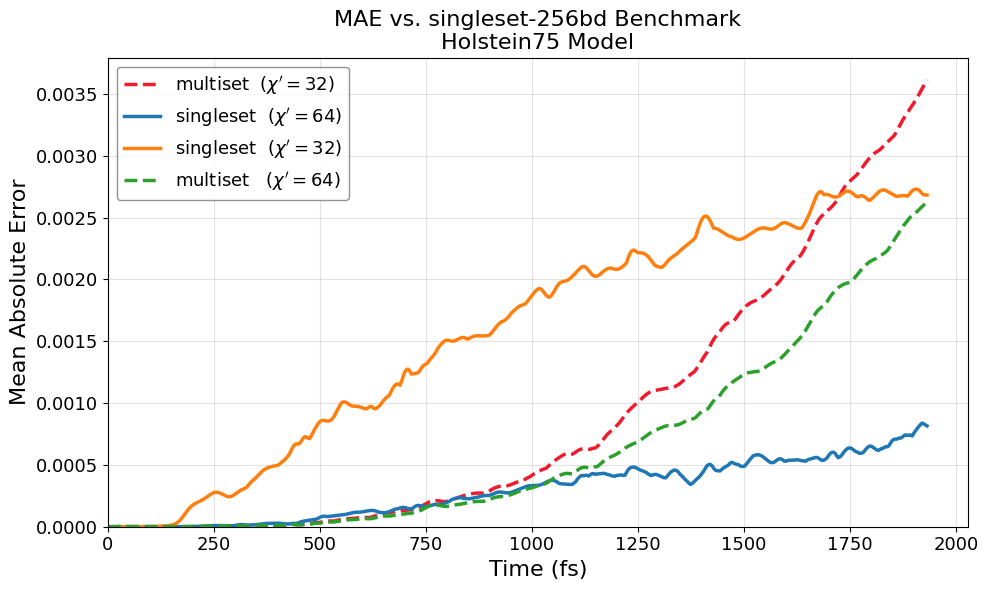

In [24]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_fmo_error():
    """
    以 singleset_256bd.xlsx 为 benchmark，
    计算其余三个文件的 Mean Absolute Error 并绘图。
    """

    # ============================================================
    # 1. 路径配置（只需修改此处）
    # ============================================================
    test_dir = "."   # ← 修改为你的文件夹路径，若在同目录则保持 "."

    benchmark_file = os.path.join(test_dir, "Holstein75_128bd_singleset.xlsx")

    # 需要对比的三个文件（按 bond dimension 从小到大排列）
    data_files = [
        os.path.join(test_dir, "Holstein75_32bd_multiset.xlsx"),
        os.path.join(test_dir, "Holstein75_64bd_singleset.xlsx"),
        os.path.join(test_dir, "Holstein75_32bd_singleset.xlsx"),
        os.path.join(test_dir, "Holstein75_64bd_multiset.xlsx"),
    ]

    # ============================================================
    # 2. 样式配置：(标签, 颜色, 线型, 线宽)
    # ============================================================
    styles = {
        "Holstein75_32bd_multiset.xlsx":  ("multiset  ($\\chi'=32$)",  "#f01b2d", "--",  2.5),
        "Holstein75_64bd_singleset.xlsx":  ("singleset  ($\\chi'=64$)",  "#1f77b4", "-",  2.5),
        "Holstein75_32bd_singleset.xlsx": ("singleset  ($\\chi'=32$)", "#ff7f0e", "-",  2.5),
        "Holstein75_64bd_multiset.xlsx":   ("multiset   ($\\chi'=64$)",  "#2ca02c", "--", 2.5),
    }

    # ============================================================
    # 3. 时间步长（单位：fs）
    #    dt = 每步原子单位数 × 0.024188843265 fs/a.u.
    #    根据实际步长修改 dt_au
    # ============================================================
    dt_au = 160                          # ← 按需修改
    dt    = dt_au * 0.024188843265       # fs

    # ============================================================
    # 4. 读取 benchmark
    # ============================================================
    if not os.path.exists(benchmark_file):
        raise FileNotFoundError(f"Benchmark 文件未找到: {benchmark_file}")

    df_bm = pd.read_excel(benchmark_file, header=None)
    n_col = df_bm.shape[1]              # 自动识别列数（FMO 通常为 7 个 site）
    y_bm  = df_bm.iloc[:, :n_col].to_numpy(dtype=float)
    x_bm  = np.arange(len(y_bm)) * dt

    print(f"Benchmark : singleset_256bd.xlsx")
    print(f"  行数={len(y_bm)}, 列数={n_col}, dt={dt:.4f} fs")
    print(f"  时间范围: 0 ~ {x_bm[-1]:.1f} fs\n")

    # ============================================================
    # 5. 绘图
    # ============================================================
    fig, ax = plt.subplots(figsize=(10, 6))

    for fpath in data_files:
        if not os.path.exists(fpath):
            print(f"  [跳过] 文件不存在: {fpath}")
            continue

        fname = os.path.basename(fpath)
        label, color, ls, lw = styles.get(fname, (fname, None, "-", 2.0))

        # 读取预测数据
        df_pred = pd.read_excel(fpath, header=None)
        y_pred  = df_pred.iloc[:, :n_col].to_numpy(dtype=float)
        x_pred  = np.arange(len(y_pred)) * dt

        # 将 benchmark 插值到预测时间轴上
        y_bm_interp = np.column_stack([
            np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(n_col)
        ])

        # 计算 Mean Absolute Error（对所有 site 取平均）
        mae = np.mean(np.abs(y_pred - y_bm_interp), axis=1)

        ax.plot(x_pred, mae,
                label=label,
                color=color,
                linestyle=ls,
                linewidth=lw)

        print(f"  [已绘制] {label}")
        print(f"    时间范围: 0 ~ {x_pred[-1]:.1f} fs,  "
              f"最大MAE={mae.max():.4e},  均值MAE={mae.mean():.4e}")

    # ============================================================
    # 6. 坐标轴与标注
    # ============================================================
    ax.set_xlabel("Time (fs)", fontsize=16)
    ax.set_ylabel("Mean Absolute Error", fontsize=16)
    ax.set_title(
        "MAE vs. singleset-256bd Benchmark\n"
        "Holstein75 Model",
        fontsize=16
    )
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, framealpha=0.85, edgecolor="gray")
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.savefig("FMO_MAE_vs_256bd.png", dpi=150)
    print("\n✅ 已保存: FMO_MAE_vs_256bd.png")
    plt.show()


plot_fmo_error()